In [1]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="LangSmith now uses UUID v7", 
    category=UserWarning,
)
warnings.filterwarnings("ignore", module="pydantic")

import os

from dotenv import load_dotenv

load_dotenv(os.path.join("..", ".env"), override=True)

%load_ext autoreload
%autoreload 2

In [2]:
from utils.utils import show_prompt
from prompts.prompts import SUBAGENT_USAGE_INSTRUCTIONS

show_prompt(SUBAGENT_USAGE_INSTRUCTIONS)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  You can delegate tasks to sub agents.                                                                          │
│                                                                                                                 │
│  <Task>                                                                                                         │
│  Your role is to coordinate research by delegating specific research tasks to sub-agents.                       │
│  </Task>                                                                                                        │
│                                                                                                                 │
│  <Available Tools>                                                                                              │
│  1. **task(description, subagent_type)**: Delegate research tasks to specialized sub-agents                     │
│      - description: Clear, specific research question or task                                                   │
│      - subagent_type: Type of agent to use (e.g., "research-agent")                                             │
│  2. **think_tool(reflection)**: Reflect on the results of each delegated task and plan next steps.              │
│      - reflection: Your details reflection on the results of the task and next steps.                           │
│                                                                                                                 │
│  **PARALLEL RESEARCH**: When you identify multiple independent research directions, make multiple **task**      │
│  tool calls in a single response to enable parallel execution. Use at most {max_concurrent_research_units}      │
│  parallel agents per iteration.                                                                                 │
│  </Available Tools>                                                                                             │
│                                                                                                                 │
│  <Hard Limits>                                                                                                  │
│  **Task Delegation Budgets** (Prevent excessive delegation):                                                    │
│  - **Bias towards focused research** - Use single agent for simple questions, multiple only when clearly        │
│  beneficial or when you have multiple independent research directions based on the user's request.              │
│  - **Stop when adequate** - Don't over-research; stop when you have sufficient information                      │
│  - **Limit iterations** - Stop after {max_researcher_iterations} task delegations if you haven't found          │
│  adequate sources                                                                                               │
│  </Hard Limits>                                                                                                 │
│                                                                                                                 │
│  <Scaling Rules>                                                                                                │
│  **Simple fact-finding, lists, and rankings** can use a single sub-agent:                                       │
│  - *Example*: "List the top 10 coffee shops in San Francisco" → Use 1 sub-agent, store in                       │
│  `findings_coffee_shops.md`                                                                                     │
│                                                                                                                 │
│  **Comparisons** can use a sub-agent for each element 

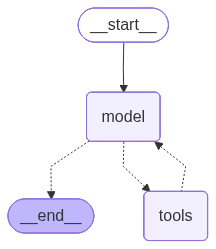

In [3]:
from langchain.tools import tool
from langchain.chat_models import init_chat_model
from utils.task_tool import _create_task_tool
from utils.state import DeepAgentState
from langchain.agents import create_agent
from prompts.prompts import SUBAGENT_USAGE_INSTRUCTIONS
from datetime import datetime


from IPython.display import Image, display

# Mock search result
search_result = """The Model Context Protocol (MCP) is an open standard protocol developed 
by Anthropic to enable seamless integration between AI models and external systems like 
tools, databases, and other services. It acts as a standardized communication layer, 
allowing AI models to access and utilize data from various sources in a consistent and 
efficient manner. Essentially, MCP simplifies the process of connecting AI assistants 
to external services by providing a unified language for data exchange. """

@tool(parse_docstring=True)
def web_search(query: str) -> str:
    """Search the web for information on a specific topic.

    This tool performs web searches and returns relevant results
    for the given query. Use this when you need to gather information from
    the internet about any topic.

    Args:
        query: The search query string. Be specific and clear about what
               information you're looking for.

    Returns:
        Search results from the search engine.

    Example:
        web_search("machine learning applications in healthcare")
    """
    return search_result

SIMPLE_RESEARCH_INSTRUCTIONS = """You are a researcher. Research the topic provided to you. IMPORTANT: Just make a single call to the web_search tool and use the result provided by the tool to answer the provided topic"""

research_sub_agent = {
    "name": "research-agent",
    "description": "Delgate research to the sub-agent researcher. Only give this researcher one topic at a time.",
    "prompt": SIMPLE_RESEARCH_INSTRUCTIONS,
    "tools": ["web_search"]
}

model = init_chat_model(model="anthropic:claude-sonnet-4-20250514", temperature=0.0)

sub_agent_tools = [web_search]

task_tool = _create_task_tool(sub_agent_tools, [research_sub_agent], model, DeepAgentState)

delegation_tools = [task_tool]

# Limits
max_concurrent_research_units = 3
max_researcher_iterations = 3

system_prompt = SUBAGENT_USAGE_INSTRUCTIONS.format(
    max_concurrent_research_units=max_concurrent_research_units,
    max_researcher_iterations=max_researcher_iterations,
    date = datetime.now().strftime("%a %b %-d, %Y")
)

agent = create_agent(
    model,
    delegation_tools,
    system_prompt=system_prompt,
    state_schema=DeepAgentState
)

# Show the agent
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [4]:
from utils.utils import format_messages

result = agent.invoke({
    "messages": [{
        "role": "user",
        "content": "Give me an overview of Model Context Protocol (MCP).",
    }]
})

format_messages(result["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Give me an overview of Model Context Protocol (MCP).                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ I'll research the Model Context Protocol (MCP) for you to provide a comprehensive overview.                     │
│                                                                                                                 │
│ 🔧 Tool Call: task                                                                                              │
│    Args: {                                                                                                      │
│   "description": "Research the Model Context Protocol (MCP) - what it is, its purpose, key features, how it     │
│ works, who developed it, current adoption status, and its significance in the AI/ML ecosystem. Include          │
│ technical details about the protocol specification, architecture, and use cases.",                              │
│   "subagent_type": "research-agent"                                                                             │
│ }                                                                                                               │
│    ID: toolu_012B3NfFXN1UVpB3XnVEKDpn                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Based on my research, here's a comprehensive overview of the Model Context Protocol (MCP):                      │
│                                                                                                                 │
│ ## What is the Model Context Protocol (MCP)?                                                                    │
│                                                                                                                 │
│ The Model Context Protocol (MCP) is an open standard protocol developed by **Anthropic** that serves as a       │
│ standardized communication layer between AI models and external systems. It enables seamless integration        │
│ between AI assistants and various external services including tools, databases, APIs, and other data sources.   │
│                                                                                                                 │
│ ## Purpose and Significance                                                                                     │
│                                                                                                                 │
│ **Primary Purpose:**                                                                                            │
│ - Standardize how AI models interact with external systems                                                      │
│ - Eliminate the need for custom integrations for each service                                                   │
│ - Provide a unified language for data exchange between AI and external tools                                    │
│ - Simplify the process of connecting AI assistants to diverse data sources                                      │
│                                                                                                                 │
│ **Significance in AI/ML Ecosystem:**                                                                            │
│ - Addresses the fragmentation problem in AI tool integration                                                    │
│ - Enables more powerful and versatile AI applications                                                           │
│ - Reduces development overhead for AI system builders                                                           │
│ - Promotes interoperability across different AI platforms and services                                          │
│                                                                                                                 │
│ ## Key Features                                                                                                 │
│                                                                                                                 │
│ 1. **Standardized Communication**: Provides a consistent protocol for AI-external system interactions           │
│ 2. **Tool Integration**: Enables AI models to access and utilize external tools seamlessly                      │
│ 3. **Database Connectivity**: Allows direct integration with various database systems                           │
│ 4. **API Standardization**: Creates uniform methods for API interactions                                        │
│ 5. **Open Standard**: Freely available for implementation across different platforms                            │
│ 6. **Extensibility**: Designed to accommodate future tools and services                                         │
│                                                                                                                 │
│ ## How It Works                                                                                                 │
│                                                                                                                 │
│ **Architecture Overview:**                             

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Based on my research, here's a comprehensive overview of the Model Context Protocol (MCP):                      │
│                                                                                                                 │
│ ## What is the Model Context Protocol (MCP)?                                                                    │
│                                                                                                                 │
│ The Model Context Protocol (MCP) is an **open standard protocol developed by Anthropic** that serves as a       │
│ standardized communication layer between AI models and external systems. It enables seamless integration        │
│ between AI assistants and various external services including tools, databases, APIs, and other data sources.   │
│                                                                                                                 │
│ ## Purpose and Key Benefits                                                                                     │
│                                                                                                                 │
│ **Primary Purpose:**                                                                                            │
│ - Standardize how AI models interact with external systems                                                      │
│ - Eliminate the need for custom integrations for each service                                                   │
│ - Provide a unified language for data exchange between AI and external tools                                    │
│ - Simplify the process of connecting AI assistants to diverse data sources                                      │
│                                                                                                                 │
│ **Key Benefits:**                                                                                               │
│ - **Reduced Development Time**: Eliminates need for custom integrations                                         │
│ - **Improved Interoperability**: Enables cross-platform compatibility                                           │
│ - **Enhanced AI Capabilities**: Allows AI models to access broader range of tools                               │
│ - **Standardization**: Creates consistency across AI implementations                                            │
│                                                                                                                 │
│ ## How It Works                                                                                                 │
│                                                                                                                 │
│ **Architecture:**                                                                                               │
│ - Acts as a middleware layer between AI models and external services                                            │
│ - Uses standardized message formats and communication protocols                                                 │
│ - Provides abstraction that hides the complexity of individual service APIs                                     │
│ - Enables bidirectional communication between AI systems and external tools                                     │
│                                                                                                                 │
│ **Technical Implementation:**                                                                                   │
│ - JSON-based message format for cross-platform compatibility                                                    │
│ - RESTful API design principles                                                                                 │
│ - Built-in versioning for protocol evolution           